<a href="https://colab.research.google.com/github/ene23033/repository/blob/master/Solcast_vs_PVMMS_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from timezonefinder import TimezoneFinder
import pvlib
from pvlib.location import Location

In [103]:
df = pd.read_csv('/content/Solcast_PVMMS_data.csv')
df.head()

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,dewpoint_temp,dhi,dni,ghi,precipitation_rate,relative_humidity,wind_direction_10m,wind_speed_10m,zenith,timestamp_x,Active_Power,Temp1,Temp2,poa
0,22,29,0,0,0,18.2,0,0,0,0.4,81.6,122,4.4,168,01-03-2015 00:00,-0.000023,20.3,20.1,-1.110
1,22,24,0,0,0,18.2,0,0,0,0.7,81.5,122,4.3,168,01-03-2015 00:05,-0.000024,20.3,20.1,-0.965
2,22,18,0,0,0,18.2,0,0,0,0.7,81.4,123,4.3,169,01-03-2015 00:10,-0.000028,20.4,20.2,-0.887
3,22,12,0,0,0,18.2,0,0,0,0.7,81.4,124,4.3,169,01-03-2015 00:15,-0.000025,20.4,20.2,-0.826
4,22,5,0,0,0,18.1,0,0,0,0.7,81.3,125,4.2,169,01-03-2015 00:20,-0.000018,20.4,20.3,-0.803


In [114]:
df=df.rename(columns={'timestamp_x':'timestamp'})
df.index = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M')

df['m'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M').dt.month
df['y'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M').dt.year
df['h'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y %H:%M').dt.hour

df.head()

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,dewpoint_temp,dhi,dni,ghi,precipitation_rate,...,Temp1,Temp2,poa,m,y,beam,sky,Solcast_poa,t,h
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-03-01 00:00:00,22,29,0,0,0,18.2,0,0,0,0.4,...,20.3,20.1,-1.110,3,2015,0.0,0.0,0.0,0,0
2015-03-01 00:05:00,22,24,0,0,0,18.2,0,0,0,0.7,...,20.3,20.1,-0.965,3,2015,0.0,0.0,0.0,0,0
2015-03-01 00:10:00,22,18,0,0,0,18.2,0,0,0,0.7,...,20.4,20.2,-0.887,3,2015,0.0,0.0,0.0,0,0
2015-03-01 00:15:00,22,12,0,0,0,18.2,0,0,0,0.7,...,20.4,20.2,-0.826,3,2015,0.0,0.0,0.0,0,0
2015-03-01 00:20:00,22,5,0,0,0,18.1,0,0,0,0.7,...,20.4,20.3,-0.803,3,2015,0.0,0.0,0.0,0,0


In [111]:
df['beam'] = pvlib.irradiance.beam_component(tilt, azimuth, df['zenith'], df['azimuth'], df['dni'])
df['sky'] = pvlib.irradiance.isotropic(tilt, df['dhi'])
df['Solcast_poa'] = df['beam']+df['sky']

In [112]:
df.to_csv('POA_solcast_SCADA.csv', index=False)

In [113]:
df.head()

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,dewpoint_temp,dhi,dni,ghi,precipitation_rate,...,Active_Power,Temp1,Temp2,poa,m,y,beam,sky,Solcast_poa,t
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-03-01 00:00:00,22,29,0,0,0,18.2,0,0,0,0.4,...,-0.000023,20.3,20.1,-1.110,3,2015,0.0,0.0,0.0,0
2015-03-01 00:05:00,22,24,0,0,0,18.2,0,0,0,0.7,...,-0.000024,20.3,20.1,-0.965,3,2015,0.0,0.0,0.0,0
2015-03-01 00:10:00,22,18,0,0,0,18.2,0,0,0,0.7,...,-0.000028,20.4,20.2,-0.887,3,2015,0.0,0.0,0.0,0
2015-03-01 00:15:00,22,12,0,0,0,18.2,0,0,0,0.7,...,-0.000025,20.4,20.2,-0.826,3,2015,0.0,0.0,0.0,0
2015-03-01 00:20:00,22,5,0,0,0,18.1,0,0,0,0.7,...,-0.000018,20.4,20.3,-0.803,3,2015,0.0,0.0,0.0,0


(-50.0, 1200.0)

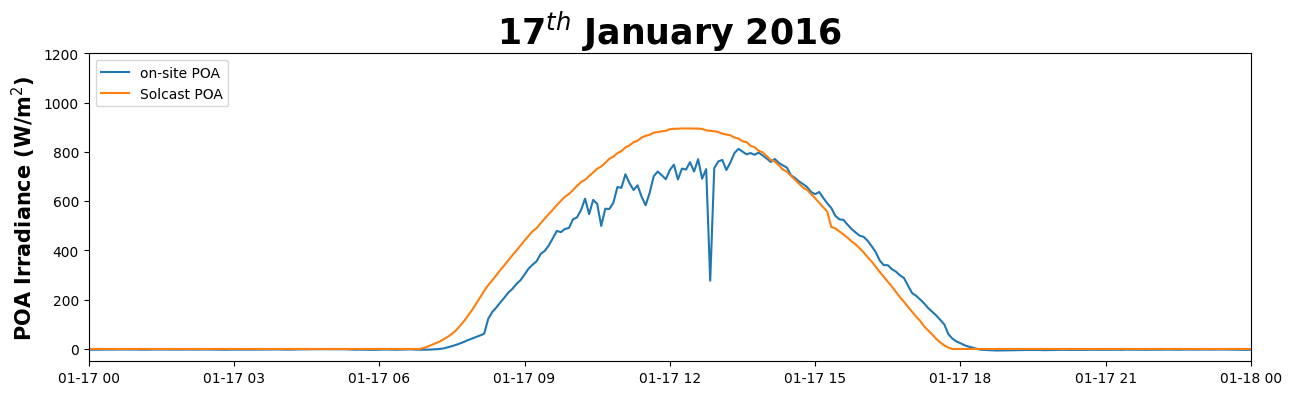

In [124]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df['poa'],  label='on-site POA')
ax.plot(df.index, df['Solcast_poa'], label='Solcast POA')
ax.set_xlim(pd.Timestamp('2016-01-17'), pd.Timestamp('2016-01-18'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('17$^{th}$ January 2016', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

(-50.0, 1200.0)

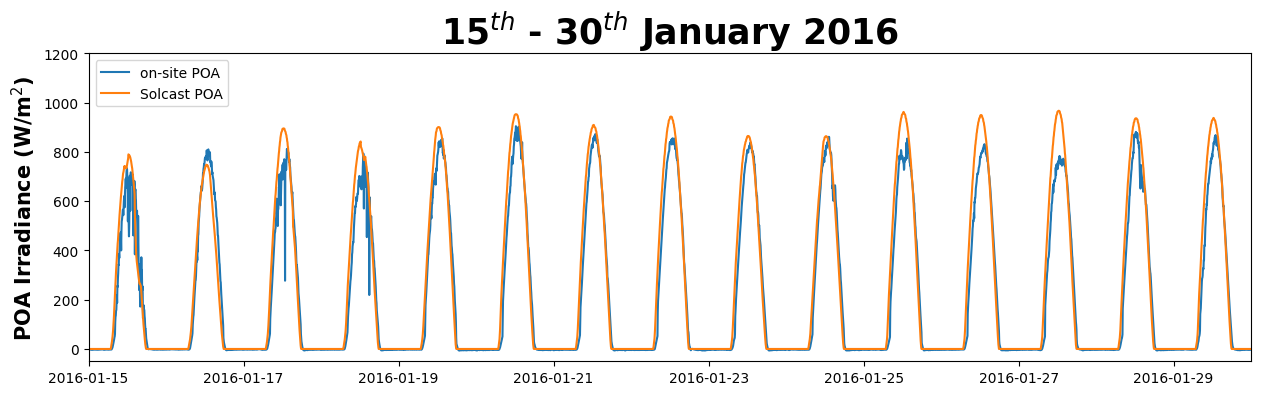

In [123]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df['poa'],  label='on-site POA')
ax.plot(df.index, df['Solcast_poa'], label='Solcast POA')
ax.set_xlim(pd.Timestamp('2016-01-15'), pd.Timestamp('2016-01-30'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('15$^{th}$ - 30$^{th}$ January 2016', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

(-50.0, 1200.0)

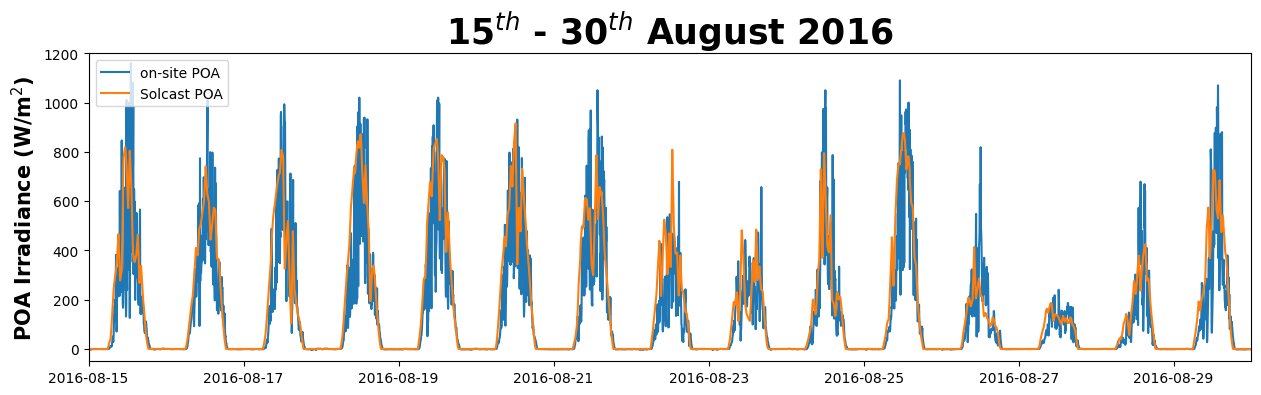

In [121]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df['poa'],  label='on-site POA')
ax.plot(df.index, df['Solcast_poa'], label='Solcast POA')
ax.set_xlim(pd.Timestamp('2016-08-15'), pd.Timestamp('2016-08-30'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('15$^{th}$ - 30$^{th}$ August 2016', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

(-50.0, 1200.0)

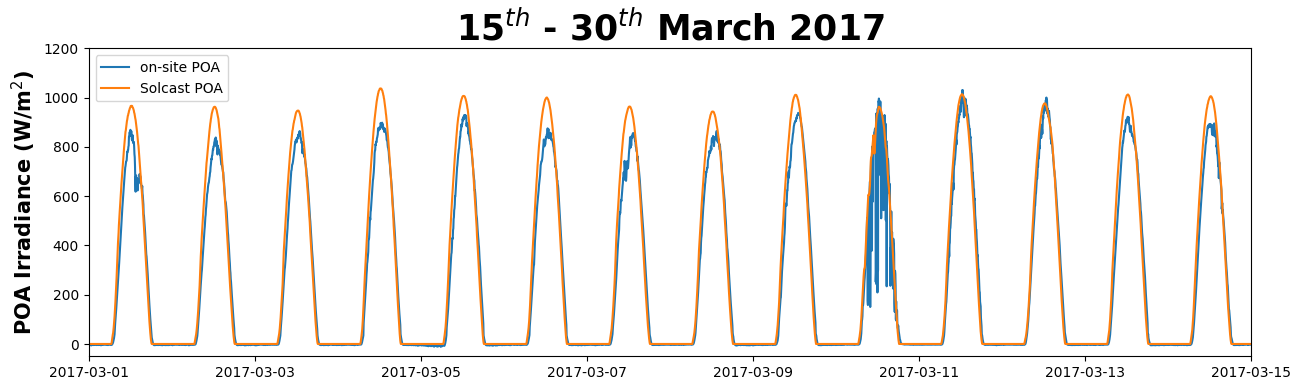

In [109]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df.index, df['poa'],  label='on-site POA')
ax.plot(df.index, df['Solcast_poa'], label='Solcast POA')
ax.set_xlim(pd.Timestamp('2017-03-01'), pd.Timestamp('2017-03-15'))
ax.set_ylabel('POA Irradiance (W/m$^2$)', fontsize=15, weight='bold')
ax.legend(loc='upper left')
ax.set_title('15$^{th}$ - 30$^{th}$ March 2017', weight='bold', fontsize=25)
ax.set_ylim(-50, 1200)

Text(0.5, 0, 'On-site POA (W/m$^2$)')

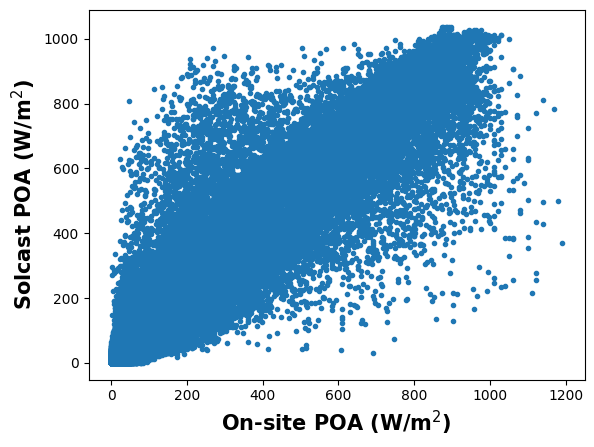

In [72]:
fig,ax = plt.subplots()
ax.plot(df['poa'][(df['poa']>0) & (df['poa']<1200)], df['Solcast_poa'][(df['poa']>0) & (df['poa']<1200)],
        'o', markersize='3')
ax.set_ylabel('Solcast POA (W/m$^2$)', weight='bold', fontsize=15)
ax.set_xlabel('On-site POA (W/m$^2$)', weight='bold', fontsize=15)

In [73]:
df['poa'][(df['poa']>0) & (df['poa']<1200)].corr(df['Solcast_poa'][(df['poa']>0) & (df['poa']<1200)])

0.9193365273706154

In [78]:
s = pd.DataFrame(df[df['y']==2016])

s['period'] = np.nan
s['period'][(s['m']>=1) & (s['m']<=4)] = 'P1'
s['period'][(s['m']>=6) & (s['m']<=9)] = 'P2'
s['period'][s['m']>9] = 'P3'

s.head()

<ipython-input-78-3f08d1db2b26>:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  s['period'][(s['m']>=1) & (s['m']<=4)] = 'P1'
<ipython-input-78-3f08d1db2b26>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,dewpoint_temp,dhi,dni,ghi,precipitation_rate,...,Temp1,Temp2,poa,beam,sky,Solcast_poa,h,y,m,period
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00,24,143,0,0,0,17.5,0,0,0,0.0,...,20.9,21.3,-3.32,0.0,0.0,0.0,0,2016,1,P1
2016-01-01 00:05:00,24,155,0,0,0,17.5,0,0,0,0.0,...,21.8,22.7,-2.99,0.0,0.0,0.0,0,2016,1,P1
2016-01-01 00:10:00,24,170,0,0,0,17.5,0,0,0,0.0,...,23.3,24.6,-3.45,0.0,0.0,0.0,0,2016,1,P1
2016-01-01 00:15:00,24,-174,0,0,0,17.5,0,0,0,0.0,...,22.1,22.7,-2.74,0.0,0.0,0.0,0,2016,1,P1
2016-01-01 00:20:00,24,-159,0,0,0,17.4,0,0,0,0.0,...,21.8,22.5,-1.68,0.0,0.0,0.0,0,2016,1,P1


(-50.0, 1200.0)

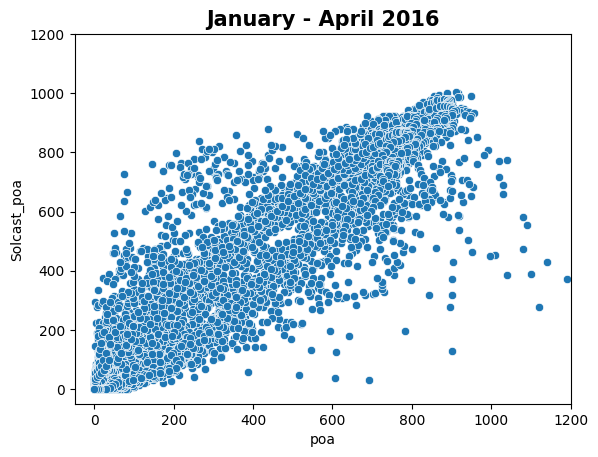

In [97]:
import seaborn as sns

sns.scatterplot(x=s['poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P1')],
                y=s['Solcast_poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P1')], data=s)
plt.title('January - April 2016', weight='bold', fontsize=15)
plt.ylim(-50, 1200)
plt.xlim(-50, 1200)

In [100]:
s['poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P1')].corr(s['Solcast_poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P1')])

0.9229853927670214

(-50.0, 1200.0)

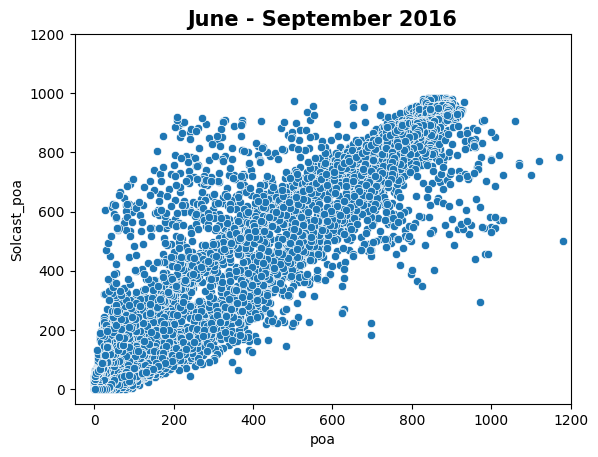

In [98]:
import seaborn as sns

sns.scatterplot(x=s['poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P2')],
                y=s['Solcast_poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P2')], data=s)
plt.title('June - September 2016', weight='bold', fontsize=15)
plt.ylim(-50, 1200)
plt.xlim(-50, 1200)

In [101]:
s['poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P2')].corr(s['Solcast_poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P2')])

0.8995474206239412

(-50.0, 1200.0)

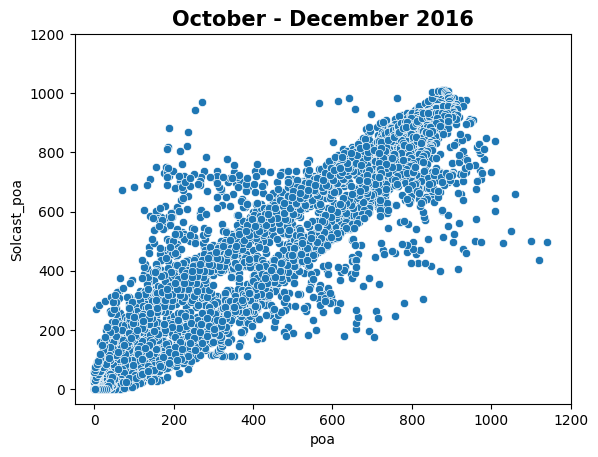

In [99]:
import seaborn as sns

sns.scatterplot(x=s['poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P3')],
                y=s['Solcast_poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P3')], data=s)
plt.title('October - December 2016', weight='bold', fontsize=15)
plt.ylim(-50, 1200)
plt.xlim(-50, 1200)

In [102]:
s['poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P3')].corr(s['Solcast_poa'][(s['poa']>0) & (s['poa']<1200) & (s['period']=='P3')])

0.9107673526703958

In [118]:
z = pd.DataFrame(df[df['y']==2016])

z['period'] = np.nan
z['period'][(z['h']>=8) & (z['h']<10)] = 'T1'
z['period'][(z['h']>=10) & (z['h']<14)] = 'T2'
z['period'][(z['h']>=14) & (z['h']<=17)] = 'T3'

z = z.dropna()
z.head()

<ipython-input-118-d99582e7e5f2>:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  z['period'][(z['h']>=8) & (z['h']<10)] = 'T1'
<ipython-input-118-d99582e7e5f2>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

,air_temp,azimuth,clearsky_dhi,clearsky_dni,clearsky_ghi,dewpoint_temp,dhi,dni,ghi,precipitation_rate,...,Temp2,poa,m,y,beam,sky,Solcast_poa,t,h,period
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-01 08:00:00,21,-122,88,405,193,15.3,88,405,193,0.0,...,24.5,38.4,1,2016,166.602586,85.602817,252.205404,8,8,T1
2016-01-01 08:05:00,21,-122,92,427,211,15.4,92,427,211,0.0,...,22.6,43.0,1,2016,182.099170,89.493854,271.593025,8,8,T1
2016-01-01 08:10:00,22,-123,97,448,228,15.5,97,448,228,0.0,...,22.3,47.9,1,2016,199.813416,94.357651,294.171066,8,8,T1
2016-01-01 08:15:00,22,-123,101,468,246,15.6,101,468,246,0.0,...,22.6,106.0,1,2016,215.663721,98.248688,313.912409,8,8,T1
2016-01-01 08:20:00,22,-124,105,487,263,15.7,105,487,263,0.0,...,25.9,165.0,1,2016,233.744173,102.139725,335.883899,8,8,T1


(-50.0, 1200.0)

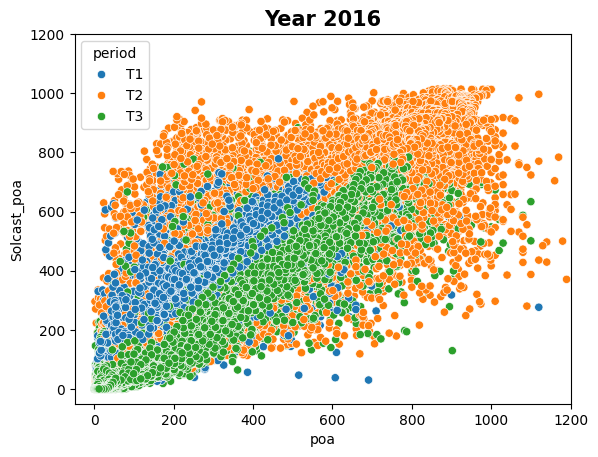

In [125]:
sns.scatterplot(x=z['poa'][(z['poa']>0) & (z['poa']<1200)],
                y=z['Solcast_poa'][(z['poa']>0) & (z['poa']<1200)],
                hue=z['period'][(z['poa']>0) & (z['poa']<1200)], data=s)
plt.title('Year 2016', weight='bold', fontsize=15)
plt.ylim(-50, 1200)
plt.xlim(-50, 1200)